# External Features Signal Pipeline

This pipeline builds the monthly external feature file used by the demand forecast.

It covers the source register, monthly feature build, checks and outputs.


## What is included

The six signal families are:

1. **CONASET collisions** - monthly collisions, casualties and timing mix.
2. **ANAC Suzuki registrations** - monthly model units and a partial fleet-age proxy.
3. **MOP road traffic** - monthly light and heavy vehicle passages, with INE transport context.
4. **CMF insured repairs** - damaged insured vehicles and repair activity, published twice a year and carried forward only after release.
5. **Weather** - monthly temperature, rain, snowfall and wind fields across the selected Chile locations.
6. **Calendar** - month length, weekends, public holidays and working days.


## Libraries and setup

The next cells load the required libraries and import the feature-building modules from `scripts/`.


In [ ]:
# Install packages missing from the active Python environment.
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "dateutil": "python-dateutil",
    "packaging": "packaging",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "openpyxl": "openpyxl",
    "pandas": "pandas",
    "pypdf": "pypdf",
    "sklearn": "scikit-learn",
    "xlrd": "xlrd",
}

missing_packages = [
    package_name
    for import_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *missing_packages,
    ])
else:
    print("All required packages are already installed.")


In [ ]:
# Standard-library imports used by setup and source parsing.
from __future__ import annotations

import json
import math
import os
import re
import sys
import tempfile
import unicodedata
from pathlib import Path

# Data, plotting, document-reading and modelling imports.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pypdf import PdfReader
from sklearn.ensemble import RandomForestRegressor

print("Libraries loaded")


Libraries loaded


## Raw source data

The pipeline reads the CONASET workbooks, ANAC reports, MOP workbooks, CMF values and cached weather/calendar extracts. All derived tables are created during the run.


In [ ]:
# Locate the repository and activate its shared Python code.
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, start.parent, start.parent.parent]
    for candidate in candidates:
        if (candidate / 'data/external').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project. Run from the repository root "
        "or the notebooks folder."
    )


project_root = find_project_root()
PROJECT_ROOT = project_root
PROJECT_CODE_ROOT = PROJECT_ROOT / 'scripts'
if str(PROJECT_CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Shared code folder: {PROJECT_CODE_ROOT}")


## Repository external-feature pipelines

CONASET, vehicle-activity and combined feature-building code is imported from `scripts/`. Derived tables remain available as dataframes throughout the run.


In [ ]:
# Import the external-feature pipeline from the repository scripts folder.
os.chdir(PROJECT_ROOT)
from build_external_features_pipeline import EXTERNAL, run_pipeline, source_registry

# A January forecast evaluated against March actuals is two months ahead.
FORECAST_LEAD_MONTHS = 2
INTERVENING_MONTHS = FORECAST_LEAD_MONTHS - 1

print(f"Project root: {PROJECT_ROOT}")
print(f"Pipeline code imported from: {PROJECT_CODE_ROOT}")
print(f"Raw external source folder: {EXTERNAL / 'External source files'}")


## Full process

This diagram shows the route from the six source families to the forecast comparison and outputs.

```mermaid
flowchart TD
    C["CONASET collisions"] --> P["Read and clean the six source families"]
    A["ANAC Suzuki registrations"] --> P
    T["MOP road traffic"] --> P
    R["CMF insured repairs"] --> P
    W["Weather"] --> P
    H["Calendar"] --> P

    P --> L["Apply release dates and monthly rules"]
    L --> Q["Registry, inventory and quality checks"]
    Q --> X["Monthly external feature table"]
    X --> J["Join collision SKU demand history"]
    J --> S["48-month train, 2-month-ahead forecast, 18-month test"]

    S --> I["Internal-only model"]
    S --> E["Internal plus external model"]
    I --> V["Compare WMAPE by demand group"]
    E --> V

    V --> O["Charts and outputs"]
```


## Pipeline code and data

Transformation code is stored in `scripts/`, and raw files are read from `data/external`. The run creates the registry, monthly feature table, inventory, quality tables and forecast checks.


## Source register

The register shows what each source contributes, how often it changes and where its limits are.
Each of the six sources has one row. CONASET uses three workbooks, but they are treated as one signal family.


In [ ]:
# Check that all six sources are registered and ready.

registry_preview = source_registry()
expected_source_ids = [
    "cl_conaset_monthly_collision_signals",
    "cl_anac_suzuki_monthly_model_sales",
    "cl_mop_ine_monthly_vehicle_passages",
    "cl_cmf_insured_vehicle_repairs",
    "cl_weather_open_meteo_daily",
    "cl_public_holidays_nager_date",
]

display(
    registry_preview[
        [
            "source_id",
            "source_name",
            "granularity",
            "forecasting_usefulness",
            "status",
            "known_limitations",
        ]
    ]
)

assert set(registry_preview["source_id"]) == set(expected_source_ids)
assert registry_preview["status"].eq("materialised").all()


,source_id,source_name,granularity,forecasting_usefulness,status,known_limitations
0,cl_conaset_monthly_collision_signals,"CONASET monthly collision, casualty, day and h...",monthly,high,materialised,Three workbooks are combined and refreshed ann...
1,cl_anac_suzuki_monthly_model_sales,ANAC Suzuki monthly model registrations and fl...,monthly,medium,materialised,ANAC top-20 coverage is partial and SKU-to-mod...
2,cl_mop_ine_monthly_vehicle_passages,MOP Vialidad monthly vehicle passages with INE...,monthly,high,materialised,Selected stations are used; missing and invali...
3,cl_cmf_insured_vehicle_repairs,CMF insured vehicle damage and repair activity,semiannual_to_monthly_step,medium,materialised,"Official releases are semiannual, so monthly v..."
4,cl_weather_open_meteo_daily,Open-Meteo monthly weather for Chile locations,daily_to_monthly,medium,materialised,The national value is an equal-weight average ...
5,cl_public_holidays_nager_date,Chile monthly calendar features,date_to_monthly,high,materialised,Regional holiday exceptions are not included.


## Build the monthly features

This run rebuilds CONASET from the source workbooks, reads the stored weather and calendar tables, and then adds ANAC, MOP and CMF.

All modelling fields are joined at month level. Publication lags are applied before the monthly feature table is written.


In [ ]:
# Build the monthly features and collect the output tables.

pipeline_outputs = run_pipeline()

source_registry_table = pipeline_outputs["registry"]
monthly_external_features = pipeline_outputs["handoff"]
feature_inventory = pipeline_outputs["inventory"]
pipeline_quality = pipeline_outputs["quality"]
conaset_quality = pipeline_outputs["conaset_quality"]
vehicle_quality = pipeline_outputs["vehicle_quality"]
materialised_sources = pipeline_outputs["materialised_sources"]

print("Monthly external feature build complete.")


Using cached MOP traffic extraction
Using cached ANAC report extraction
                         check  value  passed
               mop_source_rows     64    True
     mop_missing_source_months      4    True
     mop_invalid_source_months      1    True
            anac_report_months     66    True
anac_months_with_suzuki_models     50    True
 anac_months_with_market_total     32    True
         suzuki_model_mix_rows    528    True
            forecast_safe_rows     72    True
       handoff_duplicate_dates      0    True
           new_feature_columns     33    True
Monthly external feature build complete.


## Pipeline checks

Every check must pass. The build stops if a source is missing, a month is duplicated or an expected feature family is empty.


In [ ]:
# Stop the pipeline if any check fails.

display(pipeline_quality)
assert pipeline_quality["passed"].all()


,check,value,passed
0,Monthly rows,64,True
1,Duplicate months,0,True
2,First month,2021-01-01,True
3,Last month,2026-04-01,True
4,Sources in registry,6,True
5,Sources in inventory,6,True
6,Sources in source summary,6,True
7,Materialised registry sources,6,True
8,CONASET feature columns,35,True
9,MOP feature columns,14,True


## Monthly feature table

`monthly_external_features.csv` is the file to merge into the forecasting data.

- Grain: one row per month
- Join field: `date`
- Current range: January 2021 to April 2026
- Values: publication-safe monthly features


In [ ]:
# Summarise the monthly feature table and count features by source.

source_labels = {
    "cl_conaset_monthly_collision_signals": "CONASET",
    "cl_anac_suzuki_monthly_model_sales": "ANAC",
    "cl_mop_ine_monthly_vehicle_passages": "MOP",
    "cl_cmf_insured_vehicle_repairs": "CMF",
    "cl_weather_open_meteo_daily": "Weather",
    "cl_public_holidays_nager_date": "Calendar",
}

family_counts = (
    feature_inventory
    .groupby("source_id", as_index=False)
    .agg(feature_columns=("standard_feature_name", "nunique"))
)
family_counts["source_family"] = family_counts["source_id"].map(source_labels)
family_counts = family_counts[["source_family", "feature_columns"]].sort_values("source_family")

handoff_summary = pd.DataFrame(
    [{
        "rows": len(monthly_external_features),
        "columns": len(monthly_external_features.columns),
        "first_month": monthly_external_features["date"].min(),
        "last_month": monthly_external_features["date"].max(),
        "duplicate_months": monthly_external_features["date"].duplicated().sum(),
    }]
)

display(handoff_summary)
display(family_counts)
display(monthly_external_features.head())


,rows,columns,first_month,last_month,duplicate_months
0,64,86,2021-01-01,2026-04-01,0


,source_family,feature_columns
0,ANAC,14
1,CMF,5
2,CONASET,35
4,Calendar,4
3,MOP,14
5,Weather,11


,date,year,month,conaset_available_asof_year,conaset_available_expected5y_collisions,conaset_available_expected3y_collisions,conaset_available_last_collisions,conaset_available_expected5y_fatalities,conaset_available_expected3y_fatalities,conaset_available_last_fatalities,...,anac_available_expected3y_fleet_proxy_age_0_12m,anac_available_last_fleet_proxy_age_13_36m,anac_available_expected3y_fleet_proxy_age_13_36m,anac_available_last_fleet_proxy_age_37_60m,anac_available_expected3y_fleet_proxy_age_37_60m,cmf_available_damaged_insured_vehicles,cmf_available_insured_vehicles,cmf_available_claim_rate,cmf_available_repair_delay_days,cmf_available_report_age_months
0,2021-01-01,2021,1,2019.0,7317.2,7440.000000,7165.0,153.2,158.000000,163.0,...,0.0,0.0,0.0,0.0,0.0,100324.0,2002125.0,0.04791,76.0,1.0
1,2021-02-01,2021,2,2019.0,6772.2,6845.666667,6804.0,132.4,127.666667,130.0,...,0.0,0.0,0.0,0.0,0.0,100324.0,2002125.0,0.04791,76.0,1.0
2,2021-03-01,2021,3,2019.0,7850.2,8159.333333,8199.0,130.0,125.000000,131.0,...,0.0,0.0,0.0,0.0,0.0,100324.0,2002125.0,0.04791,76.0,1.0
3,2021-04-01,2021,4,2019.0,7526.4,7702.666667,7687.0,135.4,134.666667,130.0,...,0.0,0.0,0.0,0.0,0.0,100324.0,2002125.0,0.04791,76.0,1.0
4,2021-05-01,2021,5,2019.0,7873.2,8206.000000,8184.0,135.0,130.333333,132.0,...,0.0,0.0,0.0,0.0,0.0,100324.0,2002125.0,0.04791,76.0,1.0


## Feature inventory

The inventory links every feature to its source family and supports feature selection in the forecasting pipeline.


In [ ]:
# Link each feature back to its registered source.

inventory_summary = (
    feature_inventory
    .groupby(["source_id", "source_name"], as_index=False)
    .agg(feature_columns=("standard_feature_name", "nunique"))
    .sort_values("source_id")
)

display(inventory_summary)
display(materialised_sources[["source_id", "monthly_rows_default", "feature_columns"]])


,source_id,source_name,feature_columns
0,cl_anac_suzuki_monthly_model_sales,ANAC Suzuki monthly model registrations and fl...,14
1,cl_cmf_insured_vehicle_repairs,CMF insured vehicle damage and repair activity,5
2,cl_conaset_monthly_collision_signals,"CONASET monthly collision, casualty, day and h...",35
3,cl_mop_ine_monthly_vehicle_passages,MOP Vialidad monthly vehicle passages with INE...,14
4,cl_public_holidays_nager_date,Chile monthly calendar features,4
5,cl_weather_open_meteo_daily,Open-Meteo monthly weather for Chile locations,11


,source_id,monthly_rows_default,feature_columns
0,cl_weather_open_meteo_daily,64,"['avg_temperature', 'max_temperature', 'min_te..."
1,cl_public_holidays_nager_date,64,"['days_in_month', 'weekend_days', 'public_holi..."
2,cl_conaset_monthly_collision_signals,64,"['conaset_available_asof_year', 'conaset_avail..."
3,cl_anac_suzuki_monthly_model_sales,64,"['anac_available_last_market_units', 'anac_ava..."
4,cl_mop_ine_monthly_vehicle_passages,64,"['mop_available_last_total_passages', 'mop_ava..."
5,cl_cmf_insured_vehicle_repairs,64,"['cmf_available_damaged_insured_vehicles', 'cm..."


## Source checks and limits

- **CONASET:** true monthly history, but the official files are refreshed annually. Forecast fields only use information available by the forecast month.
- **ANAC:** monthly reports only show leading models. The fleet-age fields are partial proxies, not a complete installed fleet.
- **MOP:** selected traffic stations are used. Missing and invalid source months are shown below.
- **CMF:** the public figures are released twice a year. The monthly fields change only after a release; detailed breakdowns are not included.
- **Weather:** the national value is an equal-weight average of the selected Chile locations.
- **Calendar:** national holidays are included.


In [ ]:
# Review the source-level quality checks.

print("CONASET checks")
display(conaset_quality)

print("ANAC, MOP and CMF checks")
display(vehicle_quality)


CONASET checks


,check,value,passed
0,observed_rows,312.0,True
1,observed_duplicate_months,0.0,True
2,observed_missing_months,0.0,True
3,month_day_reconciliation_difference_cells,4.0,True
4,month_hour_reconciliation_difference_cells,4.0,True
5,month_day_reconciliation_max_abs_difference,1.0,True
6,month_hour_reconciliation_max_abs_difference,1.0,True


ANAC, MOP and CMF checks


,check,value,passed
0,mop_source_rows,64,True
1,mop_missing_source_months,4,True
2,mop_invalid_source_months,1,True
3,anac_report_months,66,True
4,anac_months_with_suzuki_models,50,True
5,anac_months_with_market_total,32,True
6,suzuki_model_mix_rows,528,True
7,forecast_safe_rows,72,True
8,handoff_duplicate_dates,0,True
9,new_feature_columns,33,True


## Output file

`data/external/monthly_external_features.csv` is the model-ready monthly feature table. It can be joined to forecasting data using `date`.


In [ ]:
# Confirm that the model-ready feature file was written.
feature_output_path = EXTERNAL / "monthly_external_features.csv"

file_summary = pd.DataFrame([{
    "file": feature_output_path.name,
    "exists": feature_output_path.exists(),
    "size_kb": round(feature_output_path.stat().st_size / 1024, 1)
    if feature_output_path.exists() else None,
    "path": str(feature_output_path),
}])

display(file_summary)
assert bool(file_summary.loc[0, "exists"])


## Use the monthly features

The forecast check joins `monthly_external_features` on the month-start `date` field. Feature selection uses training and validation data only.


## External Feature Data Check

This section compares the same demand forecast with and without the monthly external features.

## Setup and data

Load the demand history and join the monthly external features by month.

In [ ]:
# Use the project root defined during setup.
DATA_DIRECTORY = PROJECT_ROOT / "data"
EXTERNAL_DATA_DIRECTORY = DATA_DIRECTORY / "external"
PROCESSED_DEMAND_DIRECTORY = DATA_DIRECTORY / "processed" / "all_sku_history"
RESULTS_DIRECTORY = PROJECT_ROOT / "results"


In [ ]:
# Load demand and join the monthly external features.
DEMAND_TYPES_TO_RUN = ["smooth", "intermittent", "erratic", "lumpy"]
demand_paths = [
    PROCESSED_DEMAND_DIRECTORY / f"collision_sales_{demand_type}.csv"
    for demand_type in DEMAND_TYPES_TO_RUN
]
forecast_data = pd.concat([pd.read_csv(path) for path in demand_paths], ignore_index=True)
if "date" not in forecast_data.columns and "month" in forecast_data.columns:
    forecast_data = forecast_data.rename(columns={"month": "date"})


external = monthly_external_features.copy()
forecast_data["date"] = pd.to_datetime(forecast_data["date"]).dt.to_period("M").dt.to_timestamp()
external["date"] = pd.to_datetime(external["date"]).dt.to_period("M").dt.to_timestamp()

EXTERNAL_FEATURE_COLUMNS = [
    column for column in external.columns
    if column not in ["date", "year", "month"]
]
forecast_data = forecast_data.merge(external, on="date", how="left", suffixes=("", "_external"))
print(f"Loaded {len(forecast_data):,} demand rows and {len(external):,} in-memory external months.")
print(f"External candidate columns: {len(EXTERNAL_FEATURE_COLUMNS)}")
display(forecast_data.head(10))


Loaded 405,242 demand rows and 64 in-memory external months.
External candidate columns: 83


,sku_id,date,demand,demand_type,row_is_collision,COUNTRY_BRAND_CHANNEL,Country,Brand,Channel,REVENUE,...,anac_available_expected3y_fleet_proxy_age_0_12m,anac_available_last_fleet_proxy_age_13_36m,anac_available_expected3y_fleet_proxy_age_13_36m,anac_available_last_fleet_proxy_age_37_60m,anac_available_expected3y_fleet_proxy_age_37_60m,cmf_available_damaged_insured_vehicles,cmf_available_insured_vehicles,cmf_available_claim_rate,cmf_available_repair_delay_days,cmf_available_report_age_months
0,13760M56R10000,2024-09-01,13.0,Smooth,True,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,301392.0,...,6654.200000,14079.32,7466.733333,2609.5,0.000000,91840.0,2179187.0,0.042144,63.0,5.0
1,17212M76M10000,2024-08-01,2.0,Smooth,True,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,12756.0,...,6312.180000,15312.60,6943.780000,1494.3,0.000000,91840.0,2179187.0,0.042144,63.0,4.0
2,17700M62S00000,2024-02-01,11.0,Smooth,True,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,1440076.0,...,5895.680000,16965.12,4220.600000,0.0,0.000000,95921.0,2002125.0,0.047910,74.0,4.0
3,17760M76M00000,2022-12-01,0.0,Smooth,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,NaN,...,11940.320000,6853.54,0.000000,0.0,0.000000,100324.0,2002125.0,0.047910,76.0,1.0
4,17760M76M00000,2026-02-01,1.0,Smooth,True,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,61669.0,...,9305.100000,18965.44,13800.140000,15340.8,3816.500000,82697.0,2194573.0,0.037683,55.0,4.0
5,1787952R00000,2024-11-01,8.0,Smooth,True,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,100104.0,...,7485.240000,13712.72,8727.900000,4914.7,0.000000,83540.0,2157069.0,0.038728,60.0,1.0
6,2323181A20000,2021-05-01,1.0,Smooth,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,8924.0,...,0.000000,0.00,0.000000,0.0,0.000000,100324.0,2002125.0,0.047910,76.0,1.0
7,2323181A20000,2024-03-01,10.0,Smooth,True,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,54540.0,...,5895.680000,16965.12,4663.653333,0.0,0.000000,95921.0,2002125.0,0.047910,74.0,5.0
8,2323181A20000,2025-10-01,12.0,Smooth,True,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,74616.0,...,9259.693333,14246.64,12449.986667,15340.8,2065.783333,80664.0,2128128.0,0.037904,55.0,6.0
9,28130M68P005PK,2022-01-01,3.0,Smooth,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,41781.0,...,0.000000,0.00,0.000000,0.0,0.000000,100324.0,2002125.0,0.047910,76.0,1.0


## Demand groups

Use the smooth, intermittent, erratic and lumpy demand groups from the main forecast.

In [ ]:
# Count SKUs in each demand group.

sku_demand_type_distribution = (
    forecast_data
    .drop_duplicates(["sku_id", "demand_type"])
    .groupby("demand_type", as_index=False)
    .agg(
        sku_count=("sku_id", "nunique")
    )
    .sort_values("sku_count", ascending=False)
)

sku_demand_type_distribution

,demand_type,sku_count
1,Intermittent,6099
3,Smooth,904
2,Lumpy,690
0,Erratic,396


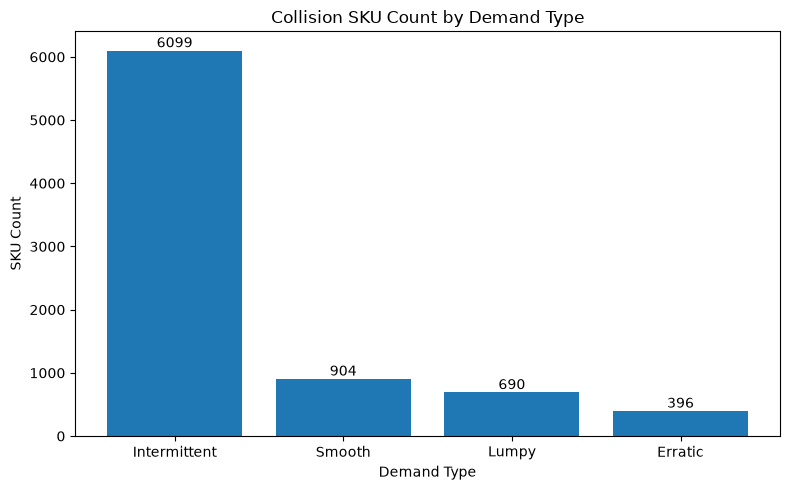

In [ ]:
# Plot the SKU count by demand group.


plt.figure(figsize=(8, 5))
bars = plt.bar(
    sku_demand_type_distribution["demand_type"],
    sku_demand_type_distribution["sku_count"]
)

plt.title("Collision SKU Count by Demand Type")
plt.xlabel("Demand Type")
plt.ylabel("SKU Count")

for bar, value in zip(
    bars,
    sku_demand_type_distribution["sku_count"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Forecast checks

Use a fixed time split with a two-month-ahead forecast. WMAPE is measured on the held-out months, and leakage fields are removed before training.

In [ ]:
# Define the time split, WMAPE and model helper functions.

# Purpose: Calculate weighted mean absolute percentage error.
def wmape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom


# Purpose: Create the chronology-safe training and two-month-ahead test periods.
def create_time_split(data, date_col="date", train_months=48, gap_months=INTERVENING_MONTHS, test_months=18):
    data = data.copy()
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col)

    last_date = data[date_col].max()

    test_end = last_date
    test_start = test_end - pd.DateOffset(months=test_months) + pd.DateOffset(months=1)

    gap_end = test_start - pd.DateOffset(months=1)
    gap_start = gap_end - pd.DateOffset(months=gap_months) + pd.DateOffset(months=1)

    train_end = gap_start - pd.DateOffset(months=1)
    train_start = train_end - pd.DateOffset(months=train_months) + pd.DateOffset(months=1)

    train = data[
        (data[date_col] >= train_start)
        & (data[date_col] <= train_end)
    ].copy()

    test = data[
        (data[date_col] >= test_start)
        & (data[date_col] <= test_end)
    ].copy()

    return train, test, {
        "train_start": train_start,
        "train_end": train_end,
        "gap_start": gap_start,
        "gap_end": gap_end,
        "test_start": test_start,
        "test_end": test_end
    }


# Purpose: Separate internal predictors from candidate external predictors.
def get_feature_sets(data, externals):
    id_cols = [
        "sku_id",
        "date",
        "demand",
        "row_is_collision",
        "is_collision",
        "collision_flag",
        "collision_flag_clean",
        "demand_type",
        "year",
        "month"
    ]

    all_external_feature_cols = [
        col for col in external.columns
        if col in data.columns
        and col not in ["date", "year", "month"]
    ]

    external_feature_cols = [
        col for col in EXTERNAL_FEATURE_COLUMNS
        if col in data.columns
    ]

    all_numeric_cols = data.select_dtypes(include="number").columns.tolist()

    internal_feature_cols = [
        col for col in all_numeric_cols
        if col not in id_cols
        and col not in all_external_feature_cols
    ]

    both_feature_cols = internal_feature_cols + external_feature_cols

    return internal_feature_cols, external_feature_cols, both_feature_cols


# Purpose: Fit one random-forest comparison and return scores, forecasts and importance.
def train_and_score_rf(train, test, feature_cols, model_name):
    X_train = train[feature_cols].fillna(0)
    y_train = train["demand"]

    X_test = test[feature_cols].fillna(0)
    y_test = test["demand"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    preds = np.clip(preds, 0, None)

    score = wmape(y_test, preds)

    feature_importance = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": model.feature_importances_
        })
        .sort_values("importance", ascending=False)
    )

    forecast_results = test[["sku_id", "date", "demand"]].copy()
    forecast_results["forecast"] = preds
    forecast_results["model"] = model_name

    return {
        "model_name": model_name,
        "wmape": score,
        "wmape_percent": score * 100,
        "feature_count": len(feature_cols),
        "model": model,
        "feature_importance": feature_importance,
        "forecast_results": forecast_results
    }

# Purpose: Select training-only external features with positive target correlation.
def select_positive_features(train, feature_cols, target_col="demand", min_corr=0):
    corr = (
        train[feature_cols + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(target_col)
        .dropna()
        .sort_values(ascending=False)
    )

    positive_features = corr[corr > min_corr].index.tolist()

    return positive_features, corr.reset_index().rename(
        columns={"index": "feature", target_col: "correlation_with_demand"}
    )

leakage_features_to_remove = [
    "REVENUE",
    "COST",
    "UNIT_PRICE",
    "TOTAL_PROFIT",
    "UNIT_COST",
    "STOCK_END_MONTH",
    "value",
    "demand",
    "total_demand",
    "mean_monthly_demand",
    "max_monthly_demand",
    "months_with_demand",
    "zero_demand_months",
    "zero_month_share",
    "cumulative_demand_share",
    "cumulative_sku_share",
    "average_demand_interval",
    "squared_coefficient_of_variation",
    "demand_type",
    "collision_flag",
    "collision_flag_clean",
    "row_is_collision",
    "is_collision",
    "month_x",
    "month_y"
]

# Purpose: Remove fields whose names indicate target leakage or unavailable future data.
def remove_likely_leakage_features(feature_cols):
    return [
        col for col in feature_cols
        if col not in leakage_features_to_remove
    ]

## Run the comparison

For each demand group, fit one internal-only model and one model with the monthly external features.

In [ ]:
# Run the internal-only and external-feature models by demand group.

demand_types_to_run = DEMAND_TYPES_TO_RUN

all_comparison_results = []
all_feature_importance = []
all_forecast_results = []
all_selected_features = []

for demand_type_to_run in demand_types_to_run:

    print(f"Running: {demand_type_to_run}")

    demand_sales = forecast_data[
        forecast_data["demand_type"].astype(str).str.lower().eq(demand_type_to_run)
    ].copy()

    if demand_sales.empty:
        print(f"Skipping {demand_type_to_run}: no rows")
        continue

    train, test, split_info = create_time_split(
        demand_sales,
        train_months=48,
        gap_months=INTERVENING_MONTHS,
        test_months=18
    )

    if train.empty or test.empty:
        print(f"Skipping {demand_type_to_run}: empty train/test")
        continue

    internal_feature_cols, external_feature_cols, both_feature_cols = get_feature_sets(
        demand_sales,
        external
    )

    internal_feature_cols = remove_likely_leakage_features(internal_feature_cols)
    both_feature_cols = remove_likely_leakage_features(both_feature_cols)

    internal_positive_features, internal_corr = select_positive_features(
        train,
        internal_feature_cols
    )

    both_positive_features, both_corr = select_positive_features(
        train,
        both_feature_cols
    )

    selected_features_summary = pd.DataFrame({
        "demand_type": demand_type_to_run,
        "model": ["Internal only", "Internal + external"],
        "feature_count_before": [len(internal_feature_cols), len(both_feature_cols)],
        "feature_count_after_positive_filter": [
            len(internal_positive_features),
            len(both_positive_features)
        ]
    })

    all_selected_features.append(selected_features_summary)

    feature_sets = {
        "Internal only": internal_positive_features,
        "Internal + external": both_positive_features
    }

    for model_label, cols in feature_sets.items():

        if len(cols) == 0:
            print(f"Skipping {demand_type_to_run} - {model_label}: no positive features")
            continue

        result = train_and_score_rf(
            train=train,
            test=test,
            feature_cols=cols,
            model_name=model_label
        )

        all_comparison_results.append({
            "demand_type": demand_type_to_run,
            "model": model_label,
            "feature_count": result["feature_count"],
            "wmape": result["wmape"],
            "wmape_percent": result["wmape_percent"],
            "train_start": split_info["train_start"],
            "train_end": split_info["train_end"],
            "test_start": split_info["test_start"],
            "test_end": split_info["test_end"],
            "train_rows": len(train),
            "test_rows": len(test),
            "sku_count": demand_sales["sku_id"].nunique()
        })

        feature_importance = result["feature_importance"].copy()
        feature_importance["demand_type"] = demand_type_to_run
        feature_importance["model"] = model_label
        feature_importance["is_external_feature"] = feature_importance["feature"].isin(
            external_feature_cols
        )

        all_feature_importance.append(feature_importance)

        forecast_results = result["forecast_results"].copy()
        forecast_results["demand_type"] = demand_type_to_run
        forecast_results["model"] = model_label

        all_forecast_results.append(forecast_results)



Running: smooth
Running: intermittent
Running: erratic
Running: lumpy


## Results

Compare WMAPE by demand group. A positive improvement means the external feature version has the lower error.

In [ ]:
# Combine the model outputs into review tables.



comparison_results_all = pd.DataFrame(all_comparison_results)

feature_importance_all = pd.concat(
    all_feature_importance,
    ignore_index=True
) if len(all_feature_importance) > 0 else pd.DataFrame()

forecast_results_all = pd.concat(
    all_forecast_results,
    ignore_index=True
) if len(all_forecast_results) > 0 else pd.DataFrame()

selected_features_all = pd.concat(
    all_selected_features,
    ignore_index=True
) if "all_selected_features" in globals() and len(all_selected_features) > 0 else pd.DataFrame()

In [ ]:
# Sort the main WMAPE comparison table.



comparison_results_all = comparison_results_all.sort_values(
    ["demand_type", "model"]
).reset_index(drop=True)

comparison_results_all

,demand_type,model,feature_count,wmape,wmape_percent,train_start,train_end,test_start,test_end,train_rows,test_rows,sku_count
0,erratic,Internal + external,43,0.705389,70.538903,2020-10-01,2024-09-01,2024-11-01,2026-04-01,15589,7050,396
1,erratic,Internal only,13,0.730870,73.086973,2020-10-01,2024-09-01,2024-11-01,2026-04-01,15589,7050,396
2,intermittent,Internal + external,42,0.373472,37.347241,2020-10-01,2024-09-01,2024-11-01,2026-04-01,181878,103967,6099
3,intermittent,Internal only,12,0.369661,36.966132,2020-10-01,2024-09-01,2024-11-01,2026-04-01,181878,103967,6099
4,lumpy,Internal + external,41,0.637886,63.788613,2020-10-01,2024-09-01,2024-11-01,2026-04-01,25998,12250,690
5,lumpy,Internal only,9,0.667169,66.716868,2020-10-01,2024-09-01,2024-11-01,2026-04-01,25998,12250,690
6,smooth,Internal + external,43,0.771644,77.164375,2020-10-01,2024-09-01,2024-11-01,2026-04-01,35685,15667,904
7,smooth,Internal only,11,0.757342,75.734216,2020-10-01,2024-09-01,2024-11-01,2026-04-01,35685,15667,904


In [ ]:
# Review how many features remain after training-only selection.



selected_features_all

,demand_type,model,feature_count_before,feature_count_after_positive_filter
0,smooth,Internal only,32,11
1,smooth,Internal + external,115,43
2,intermittent,Internal only,32,12
3,intermittent,Internal + external,115,42
4,erratic,Internal only,32,13
5,erratic,Internal + external,115,43
6,lumpy,Internal only,32,9
7,lumpy,Internal + external,115,41


In [ ]:
# Calculate the WMAPE improvement from external features.



improvement_summary = (
    comparison_results_all
    .pivot_table(
        index="demand_type",
        columns="model",
        values="wmape_percent",
        aggfunc="first"
    )
    .reset_index()
)

if "Internal only" in improvement_summary.columns and "Internal + external" in improvement_summary.columns:
    improvement_summary["external_improvement_points"] = (
        improvement_summary["Internal only"]
        - improvement_summary["Internal + external"]
    )

    improvement_summary["external_improved"] = (
        improvement_summary["external_improvement_points"] > 0
    )

improvement_summary

model,demand_type,Internal + external,Internal only,external_improvement_points,external_improved
0,erratic,70.538903,73.086973,2.548070,True
1,intermittent,37.347241,36.966132,-0.381109,False
2,lumpy,63.788613,66.716868,2.928255,True
3,smooth,77.164375,75.734216,-1.430159,False


In [ ]:
# Show the most important features for each model.



top_feature_importance = (
    feature_importance_all
    .sort_values(
        ["demand_type", "model", "importance"],
        ascending=[True, True, False]
    )
    .groupby(["demand_type", "model"])
    .head(20)
    .reset_index(drop=True)
)

top_feature_importance

,feature,importance,demand_type,model,is_external_feature
0,NEW_ENTRY_STOCK,0.949007,erratic,Internal + external,False
1,cmf_available_repair_delay_days,0.009287,erratic,Internal + external,True
2,cmf_available_damaged_insured_vehicles,0.008200,erratic,Internal + external,True
3,conaset_available_expected5y_serious_injuries,0.004611,erratic,Internal + external,True
4,Total_Vehicle_Sales,0.004120,erratic,Internal + external,False
...,...,...,...,...,...
120,Building_Permits,0.003006,smooth,Internal only,False
121,Leading_Economic_Index,0.002768,smooth,Internal only,False
122,Producer_Prices_Change,0.001295,smooth,Internal only,False
123,Inflation_Rate_MoM,0.001165,smooth,Internal only,False


In [ ]:
# Review the external features used by the models.



external_feature_importance = (
    feature_importance_all[
        feature_importance_all["is_external_feature"].eq(True)
    ]
    .sort_values(
        ["demand_type", "model", "importance"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

external_feature_importance

,feature,importance,demand_type,model,is_external_feature
0,cmf_available_repair_delay_days,0.009287,erratic,Internal + external,True
1,cmf_available_damaged_insured_vehicles,0.008200,erratic,Internal + external,True
2,conaset_available_expected5y_serious_injuries,0.004611,erratic,Internal + external,True
3,conaset_available_expected3y_serious_injuries,0.002820,erratic,Internal + external,True
4,anac_available_last_market_units,0.001771,erratic,Internal + external,True
...,...,...,...,...,...
119,mop_available_expected3y_yoy,0.000179,smooth,Internal + external,True
120,conaset_available_expected3y_total_injuries,0.000172,smooth,Internal + external,True
121,conaset_available_expected3y_night_fatality_share,0.000171,smooth,Internal + external,True
122,conaset_available_expected5y_night_collision_s...,0.000091,smooth,Internal + external,True


In [ ]:
# Aggregate forecasts to month and demand group.



forecast_by_month_type = (
    forecast_results_all
    .groupby(["demand_type", "date", "model"], as_index=False)
    .agg(
        actual=("demand", "sum"),
        forecast=("forecast", "sum")
    )
)

forecast_by_month_type

,demand_type,date,model,actual,forecast
0,erratic,2024-11-01,Internal + external,1523.0,1638.023192
1,erratic,2024-11-01,Internal only,1523.0,1492.612576
2,erratic,2024-12-01,Internal + external,1369.0,1816.363858
3,erratic,2024-12-01,Internal only,1369.0,1607.742196
4,erratic,2025-01-01,Internal + external,1471.0,1776.526113
...,...,...,...,...,...
139,smooth,2026-02-01,Internal only,4546.0,6533.260364
140,smooth,2026-03-01,Internal + external,3987.0,7535.959183
141,smooth,2026-03-01,Internal only,3987.0,7550.331343
142,smooth,2026-04-01,Internal + external,4936.0,6989.214942


## Charts and results

Show the WMAPE comparison, feature importance and actual-versus-forecast results.


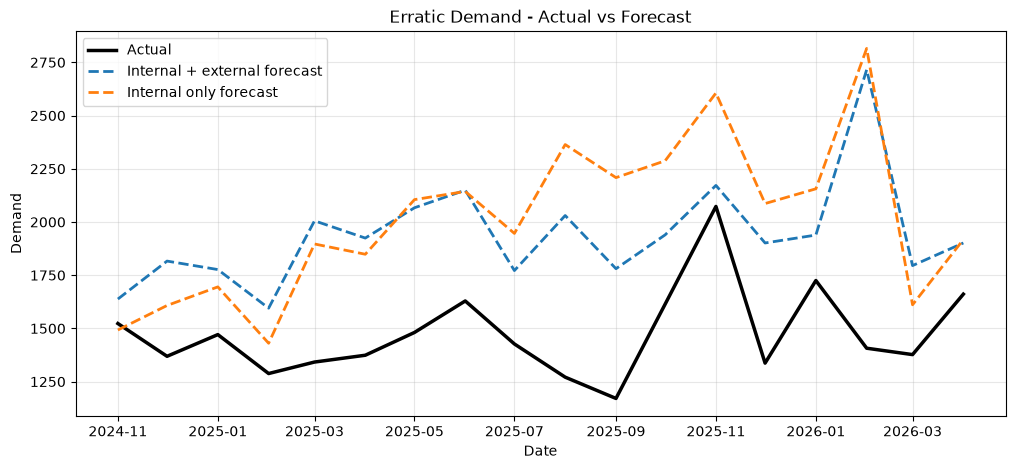

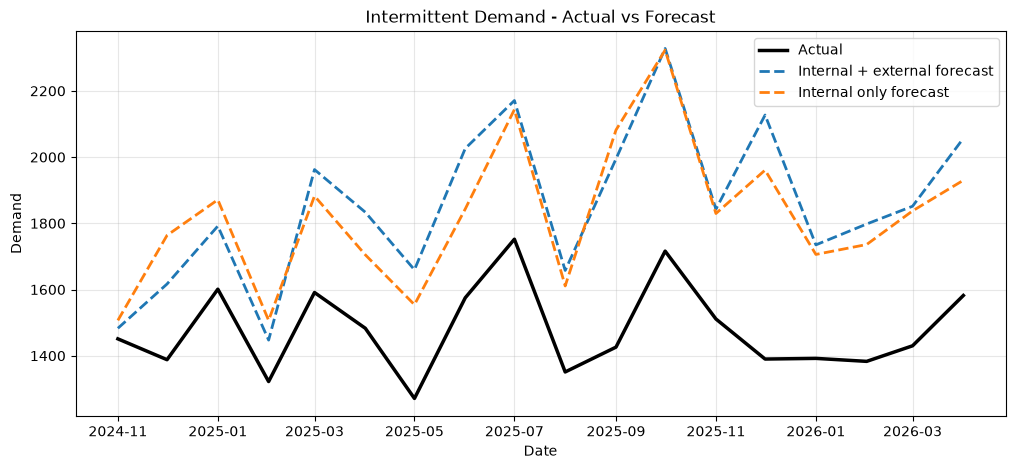

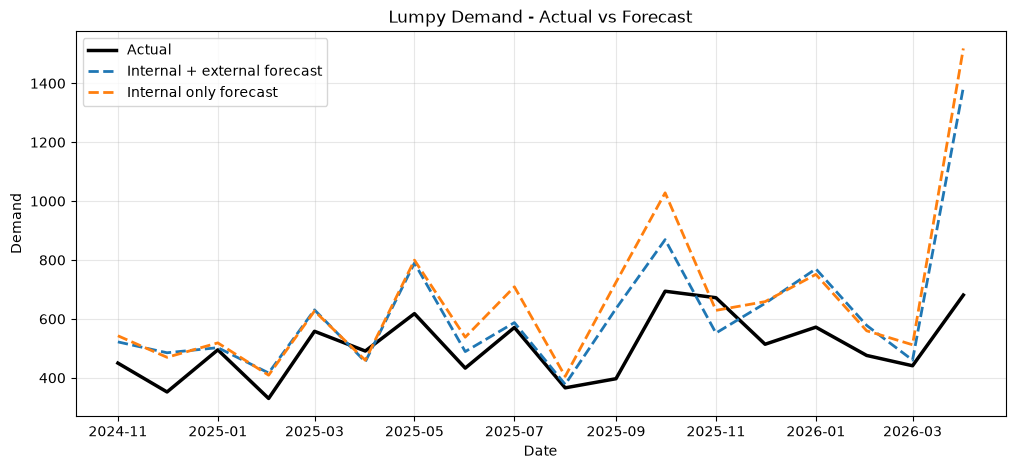

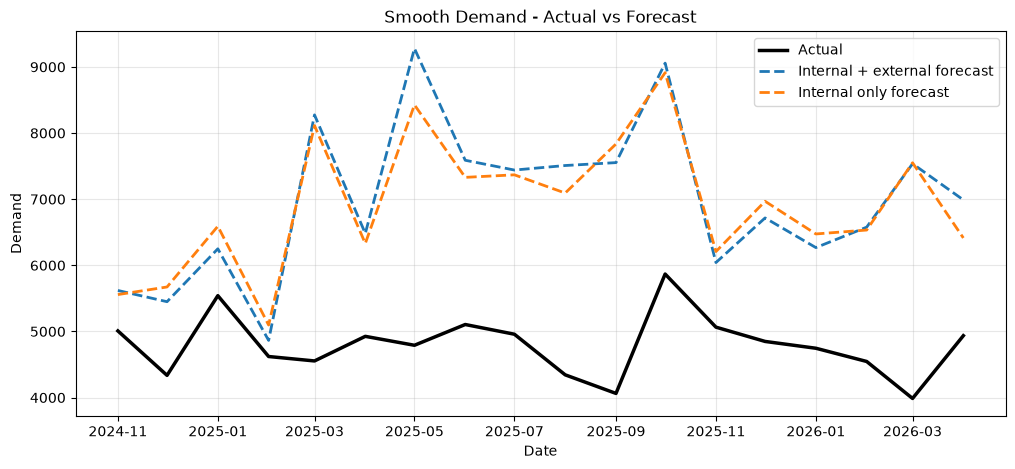

In [ ]:
# Plot WMAPE, feature importance and actual versus forecast values.




for demand_type in forecast_by_month_type["demand_type"].dropna().unique():

    plot_data = forecast_by_month_type[
        forecast_by_month_type["demand_type"].eq(demand_type)
    ].copy()

    plt.figure(figsize=(12, 5))

    actual_data = (
        plot_data
        .groupby("date", as_index=False)
        .agg(actual=("actual", "first"))
    )

    plt.plot(
        actual_data["date"],
        actual_data["actual"],
        label="Actual",
        linewidth=2.5,
        color="black"
    )

    for model_name in plot_data["model"].dropna().unique():

        model_data = plot_data[
            plot_data["model"].eq(model_name)
        ].copy()

        plt.plot(
            model_data["date"],
            model_data["forecast"],
            label=f"{model_name} forecast",
            linestyle="--",
            linewidth=2
        )

    plt.title(f"{demand_type.title()} Demand - Actual vs Forecast")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# Display the final comparison and improvement summaries.
display(comparison_results_all)
display(improvement_summary)


,demand_type,model,feature_count,wmape,wmape_percent,train_start,train_end,test_start,test_end,train_rows,test_rows,sku_count
0,erratic,Internal + external,43,0.705389,70.538903,2020-10-01,2024-09-01,2024-11-01,2026-04-01,15589,7050,396
1,erratic,Internal only,13,0.730870,73.086973,2020-10-01,2024-09-01,2024-11-01,2026-04-01,15589,7050,396
2,intermittent,Internal + external,42,0.373472,37.347241,2020-10-01,2024-09-01,2024-11-01,2026-04-01,181878,103967,6099
3,intermittent,Internal only,12,0.369661,36.966132,2020-10-01,2024-09-01,2024-11-01,2026-04-01,181878,103967,6099
4,lumpy,Internal + external,41,0.637886,63.788613,2020-10-01,2024-09-01,2024-11-01,2026-04-01,25998,12250,690
5,lumpy,Internal only,9,0.667169,66.716868,2020-10-01,2024-09-01,2024-11-01,2026-04-01,25998,12250,690
6,smooth,Internal + external,43,0.771644,77.164375,2020-10-01,2024-09-01,2024-11-01,2026-04-01,35685,15667,904
7,smooth,Internal only,11,0.757342,75.734216,2020-10-01,2024-09-01,2024-11-01,2026-04-01,35685,15667,904


model,demand_type,Internal + external,Internal only,external_improvement_points,external_improved
0,erratic,70.538903,73.086973,2.548070,True
1,intermittent,37.347241,36.966132,-0.381109,False
2,lumpy,63.788613,66.716868,2.928255,True
3,smooth,77.164375,75.734216,-1.430159,False
